# **MODELOS BASEADOS EM ÁRVORES: ÁRVORE DE REGRESSÃO, RANDOM FOREST E BOOSTING**
### **Estudo de Caso 3 — Case D: Custo em Seguro Saúde**
#### *Pós-Graduação e MBA · Analytics, Inteligência Artificial e Data Science — FIA/Labdata*
---

**Missão do estudo**

* **Predição:** identificar qual algoritmo prevê o custo anual do segurado com o menor erro possível e, a partir dele, estimar o custo de novos segurados.
* **Interpretação:** identificar quais características do segurado mais influenciam o custo anual e em que direção cada uma atua sobre as predições do modelo.

### **Bibliotecas**

In [ ]:
# Instalação de bibliotecas não disponíveis na instalação padrão do Python no Google Colab
# ! pip install shap
# ! pip install plotly
# ! pip install catboost

In [ ]:
import pandas as pd                                                                # Manipulação de dados
import numpy as np                                                                 # Realização de cálculos específicos
import plotly.express as px                                                        # Visualização de dados (interativa)
import plotly.graph_objects as go                                                  # Visualização de dados (interativa)
import plotly.io as pio                                                            # Configuração de renderização dos gráficos
from plotly.subplots import make_subplots                                          # Painéis com múltiplos gráficos
import seaborn as sns                                                              # Visualização de dados
import matplotlib.pyplot as plt                                                    # Utilizado apenas no desenho da árvore de decisão
import time                                                                        # Cálculo de tempo de execução
import math                                                                        # Funções matemáticas
from scipy.stats import randint, uniform                                           # Geração de valores aleatórios
from sklearn.compose import ColumnTransformer                                      # Transformação de colunas
from sklearn.preprocessing import StandardScaler, OneHotEncoder                    # Transformação de colunas
from sklearn.pipeline import Pipeline                                              # Encadeamento de pré-processamento e modelo
from sklearn.base import clone                                                     # Criação de cópias de modelos
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV    # Validação simples e validação cruzada
from sklearn.metrics import r2_score, root_mean_squared_error                      # Métricas de avaliação de modelos
from sklearn.tree import DecisionTreeRegressor, plot_tree                          # Árvore de regressão
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor      # Random forest e boosting
from xgboost import XGBRegressor                                                   # Boosting (XGBoost)
from lightgbm import LGBMRegressor                                                 # Boosting (LightGBM)
from sklearn.inspection import permutation_importance                              # Importância de variáveis por permutação
import shap                                                                        # Interpretabilidade de variáveis nos modelos

# Renderização dos gráficos: detecta automaticamente se o notebook está no Google Colab
try:
    import google.colab                     # noqa: F401
    pio.renderers.default = "colab"
except ImportError:
    pio.renderers.default = "notebook_connected"

# Configurações gerais
SEMENTE = 123                                             # Semente aleatória, para garantir a reprodutibilidade
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

# Padrão visual utilizado nos gráficos
TEMPLATE = 'plotly_white'
COR_1 = '#084734'
COR_2 = '#C3FA75'
COR_ALERTA = '#D62728'
ESCALA_DIVERGENTE = [[0, '#3B4CC0'], [0.5, '#DDDDDD'], [1, '#E8443A']]

### **Leitura da base de dados**

In [ ]:
# No Google Colab, faça o upload do arquivo pelo painel lateral ou monte o Google Drive antes de executar esta célula
dados = pd.read_table("Custo_Seguro_Saude_Dados.txt",
                      sep="\t",
                      decimal=".",
                      header=0)

### **Visualização da base de dados**

In [ ]:
dados.head()

,id_segurado,idade,sexo,imc,fumante,nro_condicoes_cronicas,nro_dependentes,regiao,atividade_fisica_regular,historico_familiar_doenca_grave,consumo_alcool,escolaridade,tipo_sanguineo,estado_civil,custo_anual
0,S000001,44,feminino,21.3,nao,0,0,Nordeste,sim,nao,moderado,fundamental,A+,solteiro,7974.34
1,S000002,55,feminino,26.0,nao,1,1,Sudeste,nao,nao,alto,superior,A+,casado,11798.84
2,S000003,49,feminino,15.0,nao,2,2,Norte,sim,nao,nenhum,superior,A+,uniao_estavel,10102.86
3,S000004,63,masculino,28.3,nao,1,0,Sudeste,nao,nao,baixo,medio,A+,solteiro,16028.64
4,S000005,37,masculino,24.3,nao,0,2,Sudeste,nao,nao,baixo,fundamental,B+,uniao_estavel,3272.81


### **Dimensões da base de dados**

In [ ]:
dados.shape

(2147, 15)

### **Tipos das colunas da base de dados**

In [ ]:
dados.dtypes

,0
id_segurado,object
idade,int64
sexo,object
imc,float64
fumante,object
nro_condicoes_cronicas,int64
nro_dependentes,int64
regiao,object
atividade_fisica_regular,object
historico_familiar_doenca_grave,object


### **Análise exploratória inicial**

*Análise de preenchimento (valores ausentes)*

In [ ]:
dados.isna().sum()

,0
id_segurado,0
idade,0
sexo,0
imc,0
fumante,0
nro_condicoes_cronicas,0
nro_dependentes,0
regiao,0
atividade_fisica_regular,0
historico_familiar_doenca_grave,0


In [ ]:
# Remoção de linhas com valores ausentes em qualquer coluna, caso existam
# dados = dados.dropna()

# Ou substituição de valores ausentes em uma coluna por um valor específico
# dados = dados.fillna({'imc': dados['imc'].median()})

*Estatísticas descritivas das variáveis quantitativas*

In [ ]:
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
idade,2147.0,53.55,15.90,22.00,42.00,53.00,66.0,84.00
imc,2147.0,26.87,4.47,15.00,23.75,26.90,30.0,40.90
nro_condicoes_cronicas,2147.0,1.78,1.61,0.00,1.00,1.00,3.0,8.00
nro_dependentes,2147.0,1.18,1.10,0.00,0.00,1.00,2.0,6.00
custo_anual,2147.0,14472.18,8430.12,2223.63,8519.20,12440.89,18027.8,76902.12


*Distribuição das categorias nas variáveis qualitativas*

In [ ]:
for coluna in [c for c in dados.columns
               if not pd.api.types.is_numeric_dtype(dados[c]) and dados[c].nunique() <= 30]:
    print(f"--- {coluna} ---")
    print(dados[coluna].value_counts(dropna=False), "\n")

--- sexo ---
sexo
feminino     1122
masculino    1025
Name: count, dtype: int64 

--- fumante ---
fumante
nao    1811
sim     336
Name: count, dtype: int64 

--- regiao ---
regiao
Sudeste         1005
Nordeste         381
Sul              363
Centro-Oeste     270
Norte            128
Name: count, dtype: int64 

--- atividade_fisica_regular ---
atividade_fisica_regular
nao    1366
sim     781
Name: count, dtype: int64 

--- historico_familiar_doenca_grave ---
historico_familiar_doenca_grave
nao    1666
sim     481
Name: count, dtype: int64 

--- consumo_alcool ---
consumo_alcool
baixo       851
moderado    540
nenhum      518
alto        238
Name: count, dtype: int64 

--- escolaridade ---
escolaridade
medio            858
superior         764
fundamental      318
pos_graduacao    207
Name: count, dtype: int64 

--- tipo_sanguineo ---
tipo_sanguineo
A+     748
O+     745
B+     196
O-     177
A-     166
AB+     67
B-      43
AB-      5
Name: count, dtype: int64 

--- estado_civil ---
es

*Análise de valores atípicos na variável resposta*

In [ ]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Boxplot", "Histograma"))

fig.add_trace(go.Box(y=dados['custo_anual'],
                     name="Custo Anual",
                     marker_color=COR_1,
                     boxmean=True),                       # Exibe também a média
              row=1, col=1)

fig.add_trace(go.Histogram(x=dados['custo_anual'],
                           nbinsx=40,
                           marker=dict(color=COR_1, line=dict(color='white', width=1)),
                           name="Frequência"),
              row=1, col=2)

fig.update_yaxes(title_text="Custo Anual (R$)", row=1, col=1)
fig.update_xaxes(title_text="Custo Anual (R$)", row=1, col=2)
fig.update_yaxes(title_text="Frequência", row=1, col=2)
fig.update_layout(template=TEMPLATE,
                  showlegend=False,
                  height=450,
                  title_text="Distribuição da Variável Resposta")
fig.show()

In [ ]:
# Remoção de valores atípicos na variável resposta, se necessário (exemplo: cortando pelo P99)
# corte_outliers = dados['custo_anual'].quantile(0.99)
# dados = dados[dados['custo_anual'] <= corte_outliers]

### **Etapa 1: Especificação de variáveis e análise bivariada**

*Lista de nomes das variáveis explicativas, separando em quantitativas e qualitativas*

In [ ]:
# Variável resposta e colunas que não entram no modelo
coluna_resposta = 'custo_anual'
colunas_excluidas = ['id_segurado']    # Identificador do segurado: não é característica preditiva

# Separação automática pelos tipos das colunas (ajuste manualmente, se necessário)
lista_X_quanti = [c for c in dados.columns
                  if c not in colunas_excluidas + [coluna_resposta]
                  and pd.api.types.is_numeric_dtype(dados[c])]

lista_X_quali = [c for c in dados.columns
                 if c not in colunas_excluidas + [coluna_resposta]
                 and not pd.api.types.is_numeric_dtype(dados[c])]

print("Quantitativas:", lista_X_quanti)
print("Qualitativas :", lista_X_quali)

Quantitativas: ['idade', 'imc', 'nro_condicoes_cronicas', 'nro_dependentes']
Qualitativas : ['sexo', 'fumante', 'regiao', 'atividade_fisica_regular', 'historico_familiar_doenca_grave', 'consumo_alcool', 'escolaridade', 'tipo_sanguineo', 'estado_civil']


*Objetos para variável resposta (y) e explicativas (X)*

In [ ]:
y = dados[coluna_resposta]
X = dados[lista_X_quali + lista_X_quanti]
X.head()

,sexo,fumante,regiao,atividade_fisica_regular,historico_familiar_doenca_grave,consumo_alcool,escolaridade,tipo_sanguineo,estado_civil,idade,imc,nro_condicoes_cronicas,nro_dependentes
0,feminino,nao,Nordeste,sim,nao,moderado,fundamental,A+,solteiro,44,21.3,0,0
1,feminino,nao,Sudeste,nao,nao,alto,superior,A+,casado,55,26.0,1,1
2,feminino,nao,Norte,sim,nao,nenhum,superior,A+,uniao_estavel,49,15.0,2,2
3,masculino,nao,Sudeste,nao,nao,baixo,medio,A+,solteiro,63,28.3,1,0
4,masculino,nao,Sudeste,nao,nao,baixo,fundamental,B+,uniao_estavel,37,24.3,0,2


*Análise bivariada: gráficos de boxplot para variáveis explicativas qualitativas versus variável resposta*

In [ ]:
if lista_X_quali:
    cols = 3
    rows = math.ceil(len(lista_X_quali) / cols)
    fig = make_subplots(rows=rows, cols=cols, subplot_titles=lista_X_quali)

    for i, var in enumerate(lista_X_quali):
        r, c = divmod(i, cols)
        for categoria in sorted(dados[var].dropna().unique(), key=str):
            fig.add_trace(
                go.Box(x=dados.loc[dados[var] == categoria, 'custo_anual'],
                       name=str(categoria),
                       marker_color=COR_1,
                       showlegend=False),
                row=r + 1, col=c + 1
            )

    fig.update_layout(height=450 * rows, width=1400,
                       title_text="custo_anual vs. variáveis qualitativas")
    fig.show()

*Análise bivariada: gráficos de dispersão para variáveis explicativas quantitativas versus variável resposta*

In [ ]:
if lista_X_quanti:
    dados_longo = dados[lista_X_quanti + [coluna_resposta]].melt(id_vars=coluna_resposta,
                                                                 var_name="variavel",
                                                                 value_name="valor")

    fig = px.scatter(dados_longo,
                     x="valor",
                     y=coluna_resposta,
                     facet_col="variavel",
                     facet_col_wrap=3,
                     opacity=0.35,
                     color_discrete_sequence=[COR_1],
                     trendline="lowess",                       # Tendência não paramétrica
                     trendline_color_override=COR_ALERTA,
                     template=TEMPLATE,
                     height=340 * math.ceil(len(lista_X_quanti) / 3))

    fig.update_xaxes(matches=None, showticklabels=True, title_text="")
    fig.update_yaxes(title_text="")
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_layout(title_text="Custo Anual versus Variáveis Quantitativas")
    fig.show()

*Matriz de correlações entre variáveis quantitativas e a resposta (referência auxiliar: modelos de árvore também capturam relações não lineares)*

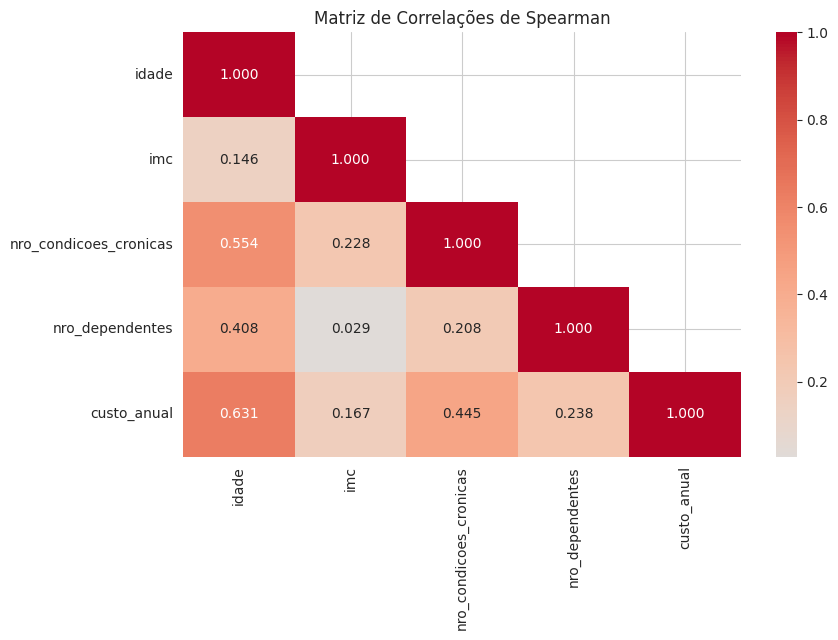

In [ ]:
if lista_X_quanti:
    matriz_cor = pd.concat([dados[lista_X_quanti], y], axis=1).corr(method='spearman').round(3)
    mask = np.triu(np.ones(matriz_cor.shape, dtype=bool), k=1)
    plt.figure(figsize=(1.2 * len(matriz_cor) + 3, 0.9 * len(matriz_cor) + 2))
    sns.heatmap(matriz_cor, mask=mask, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("Matriz de Correlações de Spearman")
    plt.tight_layout()
    plt.show()

### **Etapa 2: Divisão de treino e teste externo**

Divisão 80% / 20%, com semente aleatória fixada para garantir a reprodutibilidade.

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,
                                                        test_size=0.2,
                                                        random_state=SEMENTE)

print(f"Treino       : {X_treino.shape[0]} observações")
print(f"Teste externo: {X_teste.shape[0]} observações")

Treino       : 1717 observações
Teste externo: 430 observações


### **Etapa 3: Pré-processamento de variáveis explicativas**

*Definição das funções de pré-processamento: codificação one-hot para as variáveis qualitativas*

In [ ]:
preprocessador = ColumnTransformer(transformers=[
    # Não é necessário padronizar variáveis quantitativas em algoritmos baseados em árvores
    # ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
],
    remainder="passthrough"
)

*Criação do pré-processamento no conjunto de treino*

In [ ]:
X_treino_tratada = preprocessador.fit_transform(X_treino)  # O pré-processamento não deve envolver o conjunto de teste externo, que fica reservado apenas para a aplicação de resultados já obtidos

if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = nomes_quali + list(lista_X_quanti)

X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis, index=X_treino.index).astype(float)
X_treino_tratada.head()

,sexo_masculino,fumante_sim,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul,atividade_fisica_regular_sim,historico_familiar_doenca_grave_sim,consumo_alcool_baixo,consumo_alcool_moderado,consumo_alcool_nenhum,escolaridade_medio,escolaridade_pos_graduacao,escolaridade_superior,tipo_sanguineo_A-,tipo_sanguineo_AB+,tipo_sanguineo_AB-,tipo_sanguineo_B+,tipo_sanguineo_B-,tipo_sanguineo_O+,tipo_sanguineo_O-,estado_civil_divorciado,estado_civil_solteiro,estado_civil_uniao_estavel,estado_civil_viuvo,idade,imc,nro_condicoes_cronicas,nro_dependentes
397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,60.0,22.7,3.0,1.0
21,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,25.0,29.0,0.0,1.0
1528,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,22.9,0.0,2.0
1332,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.0,23.8,2.0,1.0
1244,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,64.0,24.1,1.0,1.0


*Aplicação do pré-processamento no conjunto de teste externo*

In [ ]:
X_teste_tratada = preprocessador.transform(X_teste)  # Note que o mesmo objeto de pré-processamento deve ser utilizado, agora com 'transform' em vez de 'fit_transform'
X_teste_tratada = pd.DataFrame(X_teste_tratada, columns=nomes_variaveis, index=X_teste.index).astype(float)
X_teste_tratada.head()

,sexo_masculino,fumante_sim,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul,atividade_fisica_regular_sim,historico_familiar_doenca_grave_sim,consumo_alcool_baixo,consumo_alcool_moderado,consumo_alcool_nenhum,escolaridade_medio,escolaridade_pos_graduacao,escolaridade_superior,tipo_sanguineo_A-,tipo_sanguineo_AB+,tipo_sanguineo_AB-,tipo_sanguineo_B+,tipo_sanguineo_B-,tipo_sanguineo_O+,tipo_sanguineo_O-,estado_civil_divorciado,estado_civil_solteiro,estado_civil_uniao_estavel,estado_civil_viuvo,idade,imc,nro_condicoes_cronicas,nro_dependentes
155,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,62.0,27.9,1.0,0.0
1801,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,47.0,24.6,0.0,0.0
228,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,27.7,3.0,1.0
403,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,20.4,1.0,1.0
1187,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,58.0,30.2,2.0,1.0


### **Etapa 4: Definição dos algoritmos e intervalos de busca de hiperparâmetros**

São testados algoritmos baseados em árvores: árvore de regressão (modelo único), *random forest* (*bagging*) e três variantes de *boosting* (*gradient boosting*, XGBoost e LightGBM).

In [ ]:
algoritmos = {

    'ÁRVORE DE REGRESSÃO': (DecisionTreeRegressor(random_state=SEMENTE), {
        'min_impurity_decrease': uniform(0, 0.05),      # Percentual mínimo de redução de impureza
        'min_samples_split': randint(20, 200),          # Qtde. mínima de observações no nó "pai"
        'min_samples_leaf': randint(10, 100),           # Qtde. mínima de observações no nó "filho"
        'max_depth': randint(2, 12)                     # Profundidade máxima da árvore
    }),

    'RANDOM FOREST': (RandomForestRegressor(random_state=SEMENTE, n_jobs=-1), {
        'n_estimators': randint(100, 500),              # Qtde. de árvores da floresta
        'max_depth': randint(3, 16),                    # Profundidade máxima de cada árvore
        'min_samples_split': randint(10, 100),          # Qtde. mínima de observações no nó "pai"
        'min_samples_leaf': randint(5, 50),             # Qtde. mínima de observações no nó "filho"
        'max_features': uniform(0.3, 0.7)               # Fração de variáveis sorteadas em cada quebra
    }),

    'GRADIENT BOOSTING': (GradientBoostingRegressor(random_state=SEMENTE), {
        'n_estimators': randint(100, 500),              # Qtde. de árvores sequenciais
        'learning_rate': uniform(0.01, 0.29),           # Taxa de aprendizado
        'max_depth': randint(2, 6),                     # Profundidade máxima de cada árvore
        'min_samples_leaf': randint(5, 50),             # Qtde. mínima de observações no nó "filho"
        'subsample': uniform(0.6, 0.4)                  # Fração de observações usada em cada etapa
    }),

    'XGBOOST': (XGBRegressor(random_state=SEMENTE, n_jobs=-1,
                             objective='reg:squarederror', verbosity=0), {
        'n_estimators': randint(100, 600),              # Qtde. de árvores sequenciais
        'learning_rate': uniform(0.01, 0.29),           # Taxa de aprendizado
        'max_depth': randint(2, 8),                     # Profundidade máxima de cada árvore
        'min_child_weight': randint(1, 20),             # Peso mínimo (soma de hessianas) no nó "filho"
        'subsample': uniform(0.6, 0.4),                 # Fração de observações usada em cada etapa
        'colsample_bytree': uniform(0.5, 0.5),          # Fração de variáveis usada em cada árvore
        'reg_lambda': uniform(0, 5)                     # Regularização L2
    }),

    'LIGHTGBM': (LGBMRegressor(random_state=SEMENTE, n_jobs=-1, verbose=-1), {
        'n_estimators': randint(100, 600),              # Qtde. de árvores sequenciais
        'learning_rate': uniform(0.01, 0.29),           # Taxa de aprendizado
        'num_leaves': randint(8, 64),                   # Qtde. máxima de folhas por árvore
        'min_child_samples': randint(10, 60),           # Qtde. mínima de observações na folha
        'subsample': uniform(0.6, 0.4),                 # Fração de observações usada em cada etapa
        'colsample_bytree': uniform(0.5, 0.5),          # Fração de variáveis usada em cada árvore
        'reg_lambda': uniform(0, 5)                     # Regularização L2
    })
}

# Opcional (vide enunciado): o CatBoost não exige codificação prévia das variáveis qualitativas,
# e a regressão linear regularizada exigiria a padronização das variáveis quantitativas.
# from catboost import CatBoostRegressor
# algoritmos['CATBOOST'] = (CatBoostRegressor(random_state=SEMENTE, verbose=0), {
#     'iterations': randint(200, 800),
#     'learning_rate': uniform(0.01, 0.29),
#     'depth': randint(3, 8),
#     'l2_leaf_reg': uniform(1, 9)
# })

### **Etapa 5: Construção dos modelos usando validação cruzada, busca aleatória e teste externo**

*Estratégia de validação cruzada (k-fold) e quantidade máxima de iterações de busca*

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
qtd_iteracoes = 30    # Qtde. de combinações de hiperparâmetros sorteadas por algoritmo (aumente se houver tempo de processamento disponível)

*Construção dos modelos*

In [ ]:
resultados = []         # Lista para armazenar resultados
contador_modelos = 0    # Contador de modelos testados

for nome_algoritmo, (classe_algoritmo, hiperparametros) in algoritmos.items():

    # Início da contagem de tempo
    inicio = time.time()

    # Busca aleatória de hiperparâmetros com validação cruzada (randomized search)
    busca = RandomizedSearchCV(
        estimator=classe_algoritmo,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        return_train_score=True,
        random_state=SEMENTE,
        n_jobs=-1
    )

    # Ajuste dos modelos
    busca.fit(X_treino_tratada, y_treino)

    # Armazenamento dos resultados da busca
    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_algoritmo": nome_algoritmo,
        "classe_algoritmo": type(classe_algoritmo).__name__,
        "hiperparametros": busca.cv_results_["params"],
        "media_erro_treino": -busca.cv_results_["mean_train_score"],
        "media_erro_teste_interno": -busca.cv_results_["mean_test_score"],
        "dp_erro_treino": busca.cv_results_["std_train_score"],
        "dp_erro_teste_interno": busca.cv_results_["std_test_score"]
    })

    # Cálculo do erro no teste externo, para cada modelo
    erro_teste = []
    for params in resultados_aux["hiperparametros"]:
        estimador = clone(classe_algoritmo).set_params(**params)
        estimador.fit(X_treino_tratada, y_treino)
        y_hat_teste = estimador.predict(X_teste_tratada)
        erro_teste.append(root_mean_squared_error(y_teste, y_hat_teste))

    # Adição da coluna de erro em teste externo e das colunas de variações absolutas de erro em relação ao treino
    resultados_aux["erro_teste_externo"] = erro_teste
    resultados_aux["var_abs_media_erro_teste_interno"] = abs(resultados_aux["media_erro_teste_interno"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_erro_teste_externo"] = abs(resultados_aux["erro_teste_externo"] - resultados_aux["media_erro_treino"])

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)

    # Fim da contagem de tempo e mensagem de finalização
    print(f"Processo concluído para o algoritmo {nome_algoritmo} em {time.time() - inicio:.1f} segundos!")

# Consolidação dos resultados de todos os algoritmos
resultados = pd.concat(resultados, ignore_index=True)
print(f"\nTotal de modelos testados: {len(resultados)}")

Processo concluído para o algoritmo ÁRVORE DE REGRESSÃO em 3.9 segundos!
Processo concluído para o algoritmo RANDOM FOREST em 164.7 segundos!
Processo concluído para o algoritmo GRADIENT BOOSTING em 131.3 segundos!
Processo concluído para o algoritmo XGBOOST em 36.8 segundos!
Processo concluído para o algoritmo LIGHTGBM em 107.3 segundos!

Total de modelos testados: 150


### **Etapa 6: Comparação de modelos**

*Ordenação dos melhores modelos*

In [ ]:
# Escolha por qual coluna ordenar
ordenar_por = "media_erro_teste_interno"
# ordenar_por = "var_abs_media_erro_teste_interno"
# ordenar_por = "var_abs_erro_teste_externo"

# Ordenação
resultados = resultados.sort_values(ordenar_por, ascending=True)

*Exibição dos melhores modelos, em formato de tabela e gráfico*

In [ ]:
pd.set_option('display.float_format', '{:.3f}'.format)  # Quantidade de casas decimais
resultados[['num_modelo',
            'nome_algoritmo',
            'media_erro_treino',
            'dp_erro_treino',
            'media_erro_teste_interno',
            'dp_erro_teste_interno',
            'var_abs_media_erro_teste_interno',
            'erro_teste_externo',
            'var_abs_erro_teste_externo']].head(10)     # Escolha quantos modelos quer exibir

,num_modelo,nome_algoritmo,media_erro_treino,dp_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_media_erro_teste_interno,erro_teste_externo,var_abs_erro_teste_externo
85,Modelo 85,GRADIENT BOOSTING,5333.133,62.200,5803.747,296.485,470.615,6408.844,1075.711
95,Modelo 95,XGBOOST,4677.224,64.789,5848.489,331.841,1171.265,6507.050,1829.827
109,Modelo 109,XGBOOST,4802.238,61.922,5849.242,299.070,1047.004,6529.796,1727.558
74,Modelo 74,GRADIENT BOOSTING,5005.401,55.131,5854.461,298.311,849.060,6501.427,1496.027
99,Modelo 99,XGBOOST,4675.405,61.695,5857.847,294.849,1182.442,6563.538,1888.133
118,Modelo 118,XGBOOST,4230.063,75.198,5881.301,376.381,1651.238,6483.883,2253.821
51,Modelo 51,RANDOM FOREST,5349.152,74.823,5937.574,270.801,588.422,6549.762,1200.610
40,Modelo 40,RANDOM FOREST,5349.587,62.015,5940.161,249.446,590.574,6563.966,1214.378
105,Modelo 105,XGBOOST,4784.440,79.036,5942.023,428.111,1157.583,6419.115,1634.674
48,Modelo 48,RANDOM FOREST,5173.083,57.893,5951.857,255.265,778.774,6571.039,1397.956


In [ ]:
dados_grafico = resultados.head(10)       # Escolha quantos modelos quer exibir
rotulos = dados_grafico["num_modelo"] + "<br>" + dados_grafico["nome_algoritmo"]

fig = go.Figure()
fig.add_bar(x=rotulos, y=dados_grafico["media_erro_treino"],
            name="Erro Médio de Treino", marker_color="lightgray")
fig.add_bar(x=rotulos, y=dados_grafico["media_erro_teste_interno"],
            name="Erro Médio de Teste Interno", marker_color=COR_1)
fig.add_bar(x=rotulos, y=dados_grafico["erro_teste_externo"],
            name="Erro de Teste Externo", marker_color=COR_2)

fig.update_traces(hovertemplate="%{x}<br>RMSE: %{y:,.2f}<extra>%{fullData.name}</extra>")
fig.update_layout(barmode="group",
                  template=TEMPLATE,
                  height=520,
                  title_text="Comparativo dos Melhores Modelos: Treino, Teste Interno e Teste Externo",
                  yaxis_title="RMSE",
                  xaxis_title="",
                  legend=dict(orientation="h", y=1.10, x=0))
fig.show()

*Melhor modelo de cada algoritmo (comparação entre técnicas)*

In [ ]:
melhores_por_algoritmo = (resultados
                          .sort_values("media_erro_teste_interno")
                          .groupby("nome_algoritmo", as_index=False)
                          .first()
                          .sort_values("media_erro_teste_interno"))

melhores_por_algoritmo[['nome_algoritmo',
                        'num_modelo',
                        'media_erro_treino',
                        'media_erro_teste_interno',
                        'dp_erro_teste_interno',
                        'var_abs_media_erro_teste_interno',
                        'erro_teste_externo']]

,nome_algoritmo,num_modelo,media_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_media_erro_teste_interno,erro_teste_externo
0,GRADIENT BOOSTING,Modelo 85,5333.133,5803.747,296.485,470.615,6408.844
3,XGBOOST,Modelo 95,4677.224,5848.489,331.841,1171.265,6507.050
2,RANDOM FOREST,Modelo 51,5349.152,5937.574,270.801,588.422,6549.762
1,LIGHTGBM,Modelo 132,4325.677,5959.245,287.659,1633.568,6579.357
4,ÁRVORE DE REGRESSÃO,Modelo 18,5750.004,6325.364,366.836,575.360,7048.150


In [ ]:
fig = go.Figure()
fig.add_bar(x=melhores_por_algoritmo["nome_algoritmo"], y=melhores_por_algoritmo["media_erro_treino"],
            name="Erro Médio de Treino", marker_color="lightgray")
fig.add_bar(x=melhores_por_algoritmo["nome_algoritmo"], y=melhores_por_algoritmo["media_erro_teste_interno"],
            name="Erro Médio de Teste Interno", marker_color=COR_1)
fig.add_bar(x=melhores_por_algoritmo["nome_algoritmo"], y=melhores_por_algoritmo["erro_teste_externo"],
            name="Erro de Teste Externo", marker_color=COR_2)

fig.update_traces(hovertemplate="%{x}<br>RMSE: %{y:,.2f}<extra>%{fullData.name}</extra>")
fig.update_layout(barmode="group",
                  template=TEMPLATE,
                  height=480,
                  title_text="Melhor Modelo de Cada Algoritmo",
                  yaxis_title="RMSE",
                  xaxis_title="",
                  legend=dict(orientation="h", y=1.12, x=0))
fig.show()

### **Etapa 7: Escolha do modelo**

O modelo final é escolhido pelo menor RMSE médio nas *folds* de teste interno, verificando também a estabilidade em relação ao treino e ao teste externo (indício de superajuste).

*Escolha do modelo*

In [ ]:
num_modelo_escolhido = resultados.iloc[0]["num_modelo"]   # Substitua manualmente, se quiser outro modelo (exemplo: "Modelo 66")
num_modelo_escolhido

'Modelo 85'

*Características do modelo escolhido*

In [ ]:
linha = resultados.loc[resultados["num_modelo"] == num_modelo_escolhido].squeeze()
nome_algoritmo = linha["nome_algoritmo"]
hiperparametros = linha["hiperparametros"]
classe = algoritmos[nome_algoritmo][0]

print(f"O modelo final adotado foi construído com o algoritmo {nome_algoritmo}, com hiperparâmetros: { {k: round(v, 4) if isinstance(v, float) else v for k, v in hiperparametros.items()} }")
print(f"\nRMSE médio de treino        : {linha['media_erro_treino']:,.2f}")
print(f"RMSE médio de teste interno : {linha['media_erro_teste_interno']:,.2f} (desvio padrão: {linha['dp_erro_teste_interno']:,.2f})")
print(f"RMSE de teste externo       : {linha['erro_teste_externo']:,.2f}")

O modelo final adotado foi construído com o algoritmo GRADIENT BOOSTING, com hiperparâmetros: {'learning_rate': np.float64(0.0949), 'max_depth': 2, 'min_samples_leaf': 18, 'n_estimators': 108, 'subsample': np.float64(0.8208)}

RMSE médio de treino        : 5,333.13
RMSE médio de teste interno : 5,803.75 (desvio padrão: 296.48)
RMSE de teste externo       : 6,408.84


*Retreino do modelo no conjunto de treino completo*

In [ ]:
modelo_final = clone(classe).set_params(**hiperparametros)
modelo_final.fit(X_treino_tratada, y_treino)

GradientBoostingRegressor(learning_rate=np.float64(0.09485040504987627),
                          max_depth=2, min_samples_leaf=18, n_estimators=108,
                          random_state=123,
                          subsample=np.float64(0.8208174887475624))

*Gráfico da árvore (exibido apenas quando o modelo escolhido é uma árvore de regressão única). Observação: os desenhos de árvore usam matplotlib, pois `plot_tree` é uma função do próprio scikit-learn; todos os demais gráficos do notebook são interativos, construídos com Plotly.*

In [ ]:
if isinstance(modelo_final, DecisionTreeRegressor):
    plt.figure(figsize=(30, 12))                        # Ajuste o tamanho da figura para obter uma melhor visualização, a depender do tamanho da árvore
    plot_tree(modelo_final,
              feature_names=X_treino_tratada.columns,   # Nomes das variáveis
              filled=True,                              # Cores de preenchimento dos nós
              fontsize=9,                               # Tamanho da fonte dos nós
              rounded=True,                             # Arredondamento de valores nos nós
              precision=2)                              # Precisão do arredondamento
    plt.show()
else:
    print(f"O modelo escolhido ({nome_algoritmo}) é um conjunto (ensemble) de árvores e, por isso, não é representável em um único gráfico de árvore.")

O modelo escolhido (GRADIENT BOOSTING) é um conjunto (ensemble) de árvores e, por isso, não é representável em um único gráfico de árvore.


*Gráfico da melhor árvore de regressão (modelo interpretável de referência)*

Mesmo quando o modelo final escolhido é um conjunto de árvores (*ensemble*), a melhor **árvore de regressão única** é exibida abaixo por ser diretamente interpretável: ela mostra explicitamente quais variáveis e quais pontos de corte segmentam a carteira, e qual é o custo anual médio previsto em cada perfil (nó folha).

In [ ]:
# Seleção do melhor modelo do algoritmo 'ÁRVORE DE REGRESSÃO'
linha_arvore = (resultados[resultados["nome_algoritmo"] == "ÁRVORE DE REGRESSÃO"]
                .sort_values("media_erro_teste_interno")
                .iloc[0])

arvore = clone(algoritmos["ÁRVORE DE REGRESSÃO"][0]).set_params(**linha_arvore["hiperparametros"])
arvore.fit(X_treino_tratada, y_treino)

print(f"{linha_arvore['num_modelo']} — hiperparâmetros: { {k: round(v, 4) if isinstance(v, float) else v for k, v in linha_arvore['hiperparametros'].items()} }")
print(f"\nRMSE médio de treino        : {linha_arvore['media_erro_treino']:,.2f}")
print(f"RMSE médio de teste interno : {linha_arvore['media_erro_teste_interno']:,.2f} (desvio padrão: {linha_arvore['dp_erro_teste_interno']:,.2f})")
print(f"RMSE de teste externo       : {linha_arvore['erro_teste_externo']:,.2f}")
print(f"\nProfundidade efetiva: {arvore.get_depth()} | Qtde. de folhas: {arvore.get_n_leaves()}")

Modelo 18 — hiperparâmetros: {'max_depth': 5, 'min_impurity_decrease': np.float64(0.0135), 'min_samples_leaf': 16, 'min_samples_split': 29}

RMSE médio de treino        : 5,750.00
RMSE médio de teste interno : 6,325.36 (desvio padrão: 366.84)
RMSE de teste externo       : 7,048.15

Profundidade efetiva: 5 | Qtde. de folhas: 29


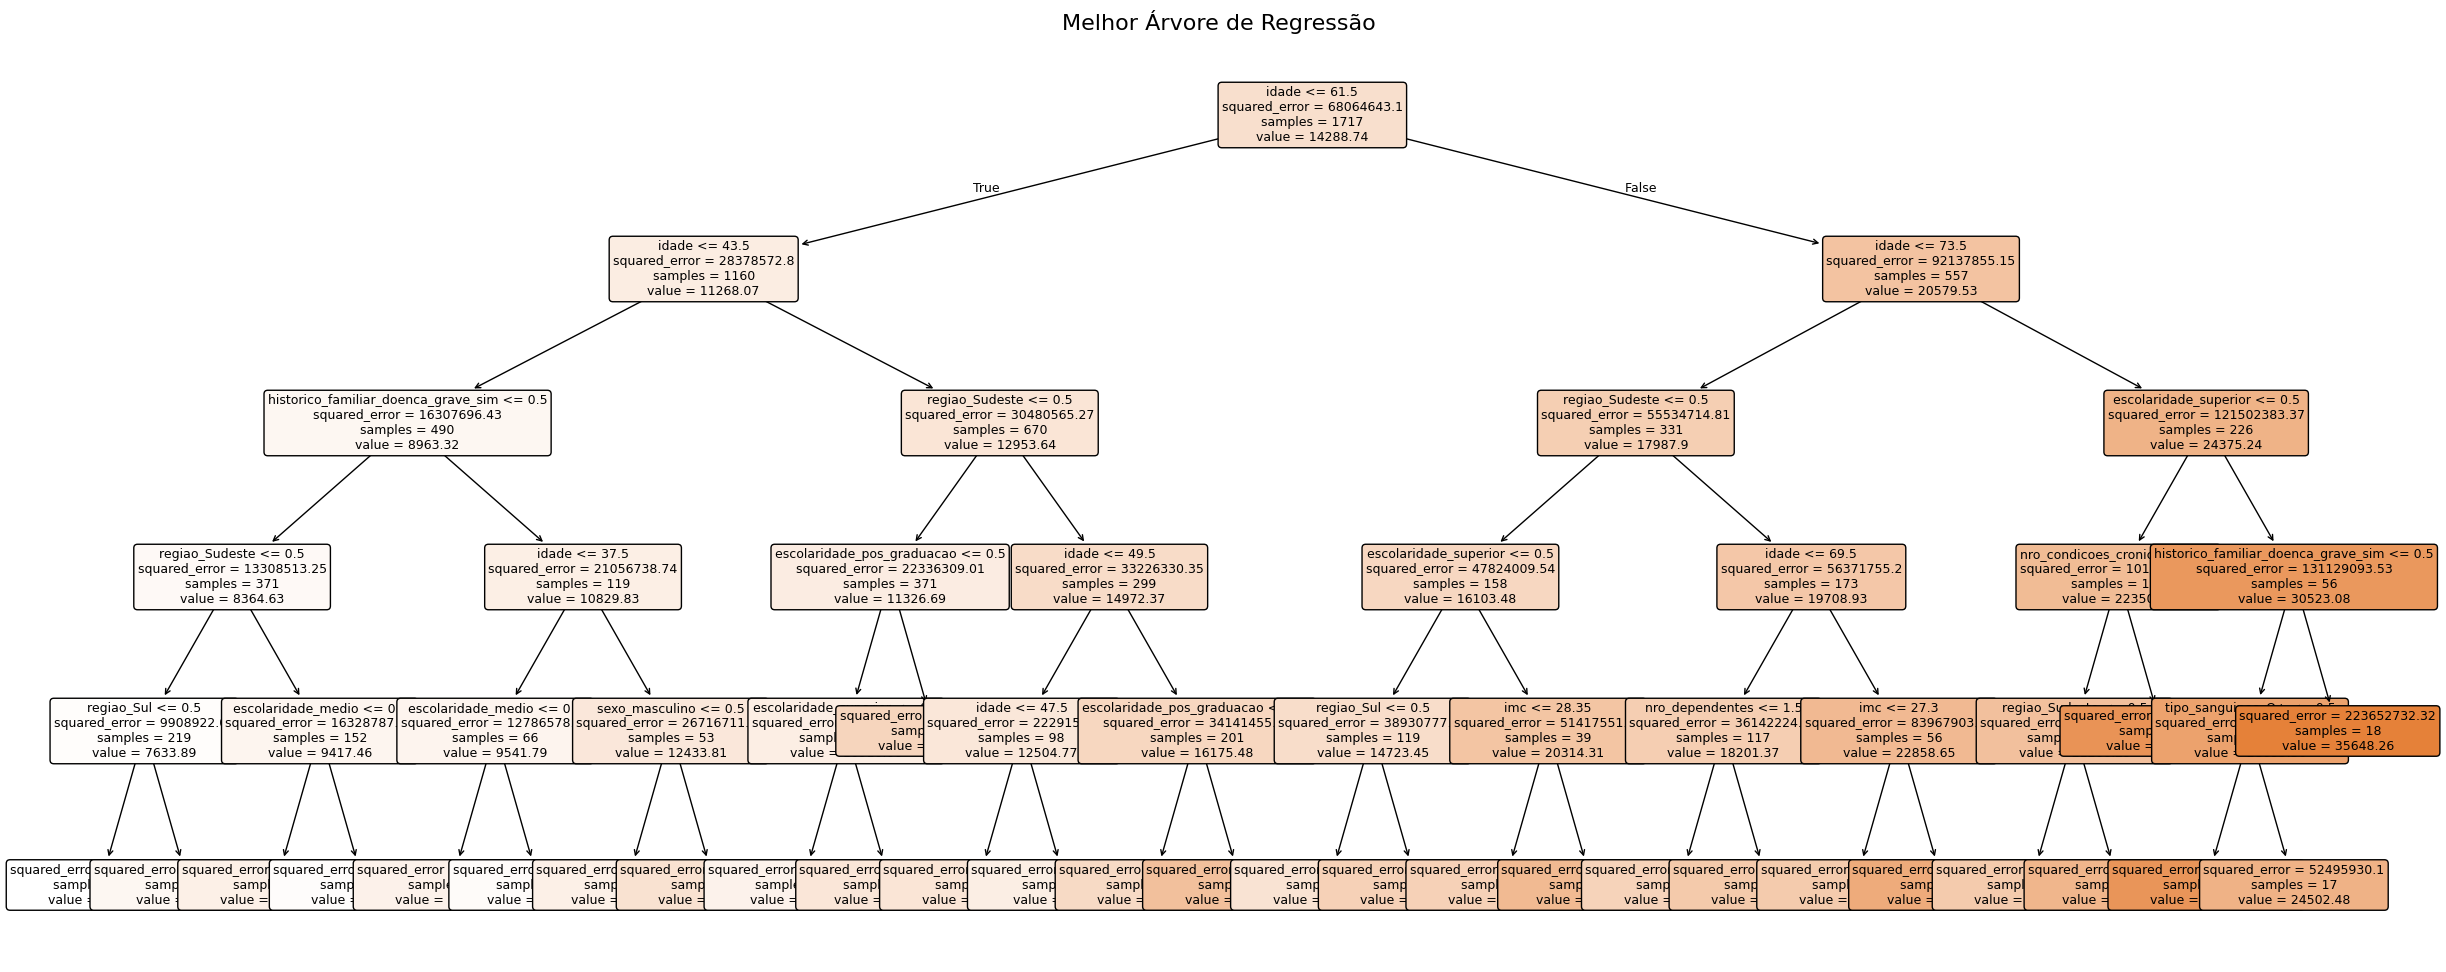

In [ ]:
plt.figure(figsize=(30, 12))                        # Ajuste o tamanho da figura para obter uma melhor visualização, a depender do tamanho da árvore
plot_tree(arvore,
          feature_names=X_treino_tratada.columns,   # Nomes das variáveis
          filled=True,                              # Cores de preenchimento dos nós
          fontsize=9,                               # Tamanho da fonte dos nós
          rounded=True,                             # Arredondamento de valores nos nós
          precision=2)                              # Precisão do arredondamento
plt.title("Melhor Árvore de Regressão", fontsize=16)
plt.show()

*Versão resumida da árvore (primeiros níveis), mais legível para apresentação*

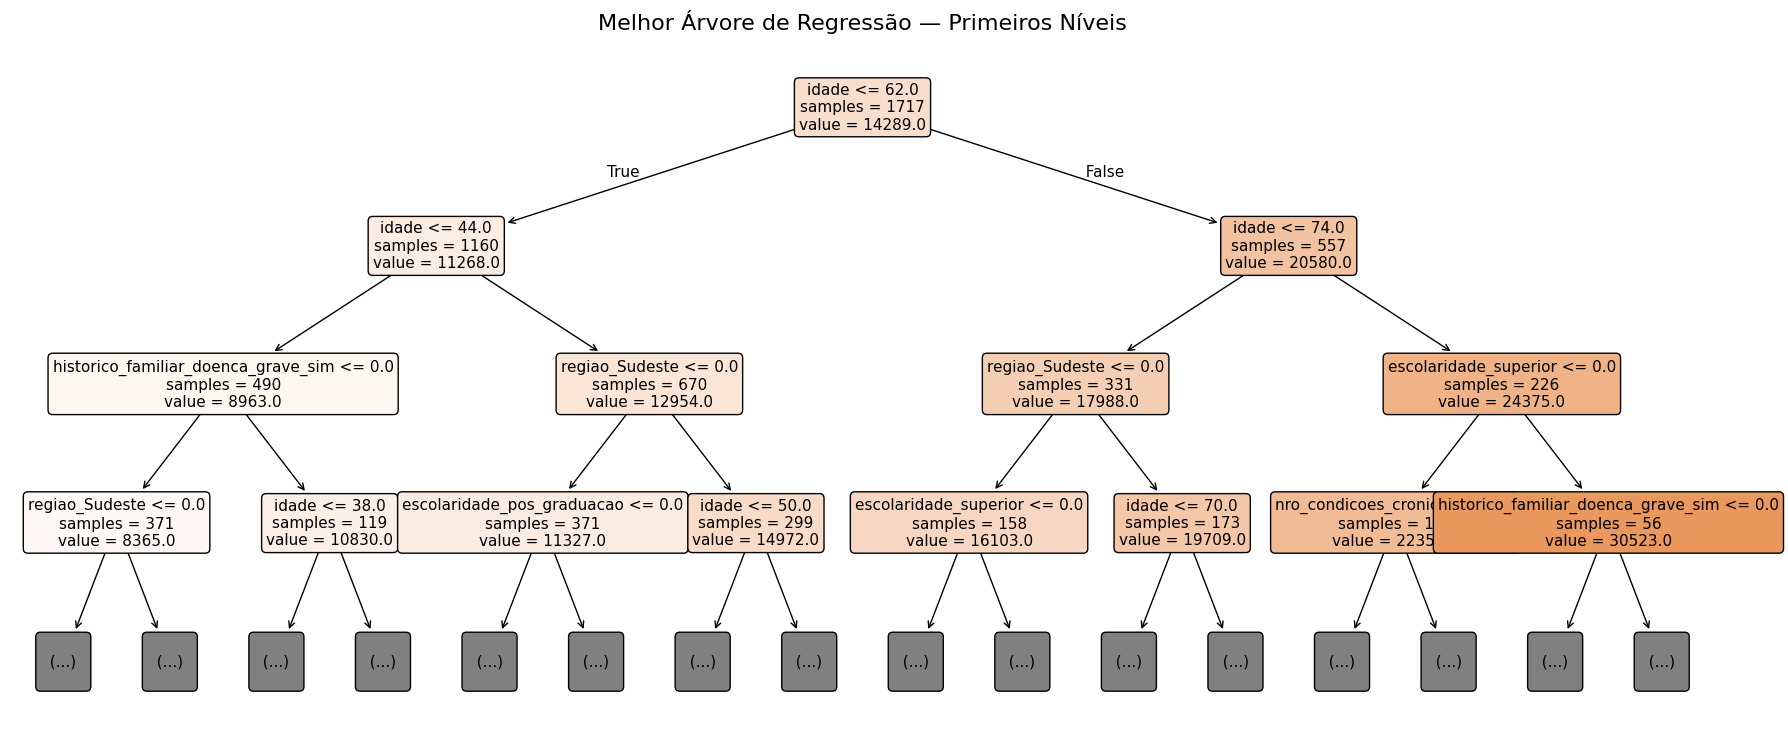

In [ ]:
plt.figure(figsize=(22, 9))
plot_tree(arvore,
          feature_names=X_treino_tratada.columns,
          filled=True,
          fontsize=11,
          rounded=True,
          precision=0,
          max_depth=3,                              # Exibe apenas os primeiros níveis
          impurity=False)
plt.title("Melhor Árvore de Regressão — Primeiros Níveis", fontsize=16)
plt.show()

*Regras de decisão da árvore em formato de texto*

In [ ]:
from sklearn.tree import export_text

print(export_text(arvore,
                  feature_names=list(X_treino_tratada.columns),
                  max_depth=3,
                  decimals=0))

|--- idade <= 62
|   |--- idade <= 44
|   |   |--- historico_familiar_doenca_grave_sim <= 0
|   |   |   |--- regiao_Sudeste <= 0
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- regiao_Sudeste >  0
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- historico_familiar_doenca_grave_sim >  0
|   |   |   |--- idade <= 38
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- idade >  38
|   |   |   |   |--- truncated branch of depth 2
|   |--- idade >  44
|   |   |--- regiao_Sudeste <= 0
|   |   |   |--- escolaridade_pos_graduacao <= 0
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- escolaridade_pos_graduacao >  0
|   |   |   |   |--- value: [16558]
|   |   |--- regiao_Sudeste >  0
|   |   |   |--- idade <= 50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- idade >  50
|   |   |   |   |--- truncated branch of depth 2
|--- idade >  62
|   |--- idade <= 74
|   |   |--- regiao_Sudeste <= 0
|   |   |   |--- escolaridade

### **Etapa 8: Avaliação de desempenho no conjunto de teste externo**

*Aplicação do modelo final no conjunto de teste externo*

In [ ]:
y_hat_teste = modelo_final.predict(X_teste_tratada)

*Métricas de desempenho: RMSE, MAE, MAPE e R²*

In [ ]:
rmse = root_mean_squared_error(y_teste, y_hat_teste)
mae = np.mean(np.abs(y_teste - y_hat_teste))
mape = np.mean(np.abs((y_teste - y_hat_teste) / y_teste))
r2 = r2_score(y_teste, y_hat_teste)

metricas = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "MAPE", "R²"],
    "Valor": [rmse, mae, mape, r2],
    "Leitura": [f"R$ {rmse:,.2f}",
                f"R$ {mae:,.2f}",
                f"{mape:.2%}",
                f"{r2:.3f}"]
})
metricas

,Métrica,Valor,Leitura
0,RMSE,6408.844,"R$ 6,408.84"
1,MAE,4594.105,"R$ 4,594.10"
2,MAPE,0.349,34.93%
3,R²,0.500,0.500


*Resíduos do modelo (e)*

In [ ]:
resid = y_teste - y_hat_teste

*Análise gráfica dos resíduos*

In [ ]:
from scipy import stats

# Percentis teóricos e amostrais para o QQ-plot
(teoricos, amostrais), (inclinacao, intercepto, _) = stats.probplot(resid, dist="norm")

min_eixo = min(y_teste.min(), y_hat_teste.min())
max_eixo = max(y_teste.max(), y_hat_teste.max())

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Histograma dos Resíduos",
                                    "Resíduos vs. Valores Preditos",
                                    "Valores Observados vs. Valores Preditos",
                                    "QQ-plot dos Resíduos"))

# (1,1) Histograma
fig.add_trace(go.Histogram(x=resid, nbinsx=40,
                           marker=dict(color=COR_1, line=dict(color="white", width=1))),
              row=1, col=1)

# (1,2) Resíduos vs. preditos
fig.add_trace(go.Scatter(x=y_hat_teste, y=resid, mode="markers",
                         marker=dict(color=COR_1, opacity=0.45, size=6)),
              row=1, col=2)
fig.add_hline(y=0, line=dict(color=COR_ALERTA, dash="dash"), row=1, col=2)

# (2,1) Observados vs. preditos
fig.add_trace(go.Scatter(x=y_teste, y=y_hat_teste, mode="markers",
                         marker=dict(color=COR_1, opacity=0.45, size=6)),
              row=2, col=1)
fig.add_trace(go.Scatter(x=[min_eixo, max_eixo], y=[min_eixo, max_eixo], mode="lines",
                         line=dict(color=COR_ALERTA, dash="dash")),
              row=2, col=1)

# (2,2) QQ-plot
fig.add_trace(go.Scatter(x=teoricos, y=amostrais, mode="markers",
                         marker=dict(color=COR_1, opacity=0.5, size=6)),
              row=2, col=2)
fig.add_trace(go.Scatter(x=teoricos, y=intercepto + inclinacao * teoricos, mode="lines",
                         line=dict(color=COR_ALERTA, dash="dash")),
              row=2, col=2)

fig.update_xaxes(title_text="Resíduos", row=1, col=1)
fig.update_yaxes(title_text="Frequência", row=1, col=1)
fig.update_xaxes(title_text="Valores Preditos", row=1, col=2)
fig.update_yaxes(title_text="Resíduos", row=1, col=2)
fig.update_xaxes(title_text="Valores Observados", row=2, col=1)
fig.update_yaxes(title_text="Valores Preditos", row=2, col=1)
fig.update_xaxes(title_text="Percentis Teóricos", row=2, col=2)
fig.update_yaxes(title_text="Percentis Amostrais", row=2, col=2)

fig.update_layout(template=TEMPLATE, height=820, showlegend=False,
                  title_text="Análise Gráfica dos Resíduos")
fig.show()

### **Etapa 9: Interpretabilidade do modelo final**

*Cálculo da importância em redução de impureza para cada variável no modelo final*

In [ ]:
importancias_impureza = pd.Series(modelo_final.feature_importances_,
                                  index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias em redução de impureza*

In [ ]:
principais = importancias_impureza.tail(15)

fig = go.Figure(go.Bar(x=principais.values,
                       y=principais.index,
                       orientation="h",
                       marker_color=COR_1,
                       hovertemplate="%{y}<br>Importância: %{x:.4f}<extra></extra>"))
fig.update_layout(template=TEMPLATE,
                  height=560,
                  title_text="Importância das Variáveis por Redução de Impureza",
                  xaxis_title="Redução Média de Impureza nas Quebras",
                  yaxis_title="")
fig.show()

*Cálculo da importância por permutação para cada variável no modelo final*

In [ ]:
importancias_permutacao = permutation_importance(modelo_final,
                                                 X_treino_tratada,
                                                 y_treino,
                                                 n_repeats=10,
                                                 random_state=SEMENTE,
                                                 scoring='neg_root_mean_squared_error')
importancias_permutacao = pd.Series(importancias_permutacao.importances_mean,
                                    index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias por permutação*

In [ ]:
principais = importancias_permutacao.tail(15)

fig = go.Figure(go.Bar(x=principais.values,
                       y=principais.index,
                       orientation="h",
                       marker_color=COR_1,
                       hovertemplate="%{y}<br>Impacto no RMSE: %{x:,.2f}<extra></extra>"))
fig.update_layout(template=TEMPLATE,
                  height=560,
                  title_text="Importância das Variáveis por Permutação",
                  xaxis_title="Impacto Médio na Medida de Erro (RMSE)",
                  yaxis_title="")
fig.show()

*Comparação entre os dois métodos de importância*

In [ ]:
comparacao_importancias = pd.DataFrame({
    "importancia_impureza": importancias_impureza,
    "importancia_permutacao": importancias_permutacao
}).sort_values("importancia_permutacao", ascending=False)

comparacao_importancias["ranking_impureza"] = comparacao_importancias["importancia_impureza"].rank(ascending=False).astype(int)
comparacao_importancias["ranking_permutacao"] = comparacao_importancias["importancia_permutacao"].rank(ascending=False).astype(int)
comparacao_importancias.head(15)

,importancia_impureza,importancia_permutacao,ranking_impureza,ranking_permutacao
idade,0.664,3663.080,1,1
escolaridade_superior,0.052,407.655,4,2
escolaridade_pos_graduacao,0.040,363.122,5,3
regiao_Sudeste,0.066,359.312,2,4
nro_condicoes_cronicas,0.059,175.205,3,5
historico_familiar_doenca_grave_sim,0.036,173.201,6,6
imc,0.036,125.716,7,7
escolaridade_medio,0.008,64.187,9,8
regiao_Norte,0.013,48.083,8,9
regiao_Sul,0.007,36.852,10,10


*Cálculo dos valores SHAP das variáveis no modelo final*

In [ ]:
# Amostragem para viabilizar o cálculo em bases grandes
amostra_shap = X_treino_tratada.sample(n=min(2000, len(X_treino_tratada)), random_state=SEMENTE)

explainer = shap.TreeExplainer(modelo_final)
valores_shap = explainer(amostra_shap)

*Gráfico de valores absolutos médios de SHAP*

In [ ]:
# Importância SHAP: média dos valores absolutos por variável
importancia_shap = pd.Series(np.abs(valores_shap.values).mean(axis=0),
                             index=amostra_shap.columns).sort_values()
principais_shap = importancia_shap.tail(15)

fig = go.Figure(go.Bar(x=principais_shap.values,
                       y=principais_shap.index,
                       orientation="h",
                       marker_color=COR_1,
                       text=[f"R$ {v:,.0f}" for v in principais_shap.values],
                       textposition="outside",
                       hovertemplate="%{y}<br>|SHAP| médio: R$ %{x:,.2f}<extra></extra>"))
fig.update_layout(template=TEMPLATE,
                  height=560,
                  title_text="Importância das Variáveis pelos Valores SHAP",
                  xaxis_title="Média dos Valores Absolutos de SHAP (R$)",
                  yaxis_title="")
fig.show()

*Gráfico de direção do impacto baseado em SHAP (beeswarm)*

In [ ]:
qtd_exibir = 15
ordem = importancia_shap.tail(qtd_exibir).index.tolist()   # Da menos para a mais importante (eixo Y de baixo para cima)
gerador = np.random.default_rng(SEMENTE)

pontos = []
for i, var in enumerate(ordem):
    sh = valores_shap.values[:, amostra_shap.columns.get_loc(var)]
    valor = amostra_shap[var].values

    # Deslocamento vertical proporcional à densidade local, para criar o efeito de "enxame"
    faixas = np.digitize(sh, np.linspace(sh.min(), sh.max() + 1e-9, 60))
    deslocamento = np.zeros(len(sh))
    for faixa in np.unique(faixas):
        m = faixas == faixa
        deslocamento[m] = gerador.permutation(np.linspace(-0.35, 0.35, m.sum())) if m.sum() > 1 else 0

    pontos.append(pd.DataFrame({
        "shap": sh,
        "y": i + deslocamento,
        "cor": pd.Series(valor).rank(pct=True).values,   # Percentil do valor da variável
        "variavel": var,
        "valor": valor
    }))

pontos = pd.concat(pontos, ignore_index=True)

fig = go.Figure(go.Scatter(
    x=pontos["shap"],
    y=pontos["y"],
    mode="markers",
    marker=dict(size=5,
                color=pontos["cor"],
                colorscale=ESCALA_DIVERGENTE,
                showscale=True,
                colorbar=dict(title="Valor da<br>variável",
                              tickvals=[0.03, 0.97],
                              ticktext=["Baixo", "Alto"])),
    customdata=np.stack([pontos["variavel"], pontos["valor"]], axis=-1),
    hovertemplate="%{customdata[0]} = %{customdata[1]:.2f}<br>SHAP: R$ %{x:,.0f}<extra></extra>"))

fig.add_vline(x=0, line=dict(color="gray", width=1))
fig.update_layout(template=TEMPLATE,
                  height=680,
                  title_text="Dispersão dos Valores SHAP (beeswarm): Direção do Efeito de Cada Variável",
                  xaxis_title="Valor SHAP — impacto sobre a predição de custo anual (R$)",
                  yaxis=dict(tickmode="array",
                             tickvals=list(range(len(ordem))),
                             ticktext=ordem,
                             title=""))
fig.show()

*Explicação individual de uma observação (waterfall)*

In [ ]:
# Exemplo para a primeira observação da amostra
i_obs = 0
qtd_exibir_wf = 12

contribuicoes = pd.Series(valores_shap.values[i_obs], index=amostra_shap.columns)
principais_wf = contribuicoes.abs().sort_values(ascending=False).head(qtd_exibir_wf).index
outras = contribuicoes.drop(principais_wf).sum()
ordenadas = contribuicoes[principais_wf].reindex(contribuicoes[principais_wf].abs().sort_values(ascending=False).index)

rotulos = [f"{v} = {amostra_shap.iloc[i_obs][v]:,.2f}" for v in ordenadas.index] + ["Demais variáveis"]
valores = list(ordenadas.values) + [outras]

fig = go.Figure(go.Waterfall(
    orientation="v",
    measure=["absolute"] + ["relative"] * len(valores) + ["total"],
    x=["Valor esperado E[f(x)]"] + rotulos + ["Predição f(x)"],
    y=[valores_shap.base_values[i_obs]] + valores + [0],
    text=[f"R$ {v:,.0f}" for v in [valores_shap.base_values[i_obs]] + valores + [valores_shap.base_values[i_obs] + sum(valores)]],
    textposition="outside",
    increasing=dict(marker_color="#E8443A"),
    decreasing=dict(marker_color="#3B4CC0"),
    totals=dict(marker_color=COR_1),
    connector=dict(line=dict(color="lightgray"))))

fig.update_layout(template=TEMPLATE,
                  height=620,
                  title_text=f"Decomposição SHAP da Predição — Observação {amostra_shap.index[i_obs]}",
                  yaxis_title="Custo Anual Previsto (R$)",
                  xaxis_tickangle=-40,
                  showlegend=False)
fig.show()

### **Etapa 10: Reajuste do modelo final na base completa e predição de novos segurados**

*Reajuste na base completa (100% das observações), encadeando pré-processamento e algoritmo em um pipeline*

In [ ]:
pipeline_final = Pipeline(steps=[
    ("preprocessamento", ColumnTransformer(transformers=[
        ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
    ], remainder="passthrough")),
    ("modelo", clone(classe).set_params(**hiperparametros))
])

pipeline_final.fit(X, y)
print(f"Modelo final ({nome_algoritmo}) reajustado sobre as {len(X)} observações da base completa.")

Modelo final (GRADIENT BOOSTING) reajustado sobre as 2147 observações da base completa.


*Criação de novo objeto 'X' com as características do(s) novo(s) segurado(s)*

In [ ]:
# Os nomes das colunas e os tipos das variáveis devem ser idênticos aos da base utilizada na construção do modelo,
# e as categorias informadas devem existir na base original (consulte 'dados[coluna].unique()' em caso de dúvida)
X_novo = pd.DataFrame([
    # Segurado 1: perfil de menor risco
    {'idade': 30, 'imc': 23.0, 'nro_condicoes_cronicas': 0, 'nro_dependentes': 0,
     'sexo': 'masculino', 'regiao': 'Sudeste', 'fumante': 'nao',
     'atividade_fisica_regular': 'sim', 'historico_familiar_doenca_grave': 'nao',
     'consumo_alcool': 'baixo', 'escolaridade': 'superior', 'tipo_sanguineo': 'O+',
     'estado_civil': 'solteiro'},

    # Segurado 2: perfil intermediário
    {'idade': 50, 'imc': 27.0, 'nro_condicoes_cronicas': 2, 'nro_dependentes': 1,
     'sexo': 'feminino', 'regiao': 'Sul', 'fumante': 'nao',
     'atividade_fisica_regular': 'sim', 'historico_familiar_doenca_grave': 'nao',
     'consumo_alcool': 'moderado', 'escolaridade': 'medio', 'tipo_sanguineo': 'A+',
     'estado_civil': 'casado'},

    # Segurado 3: perfil de maior risco
    {'idade': 68, 'imc': 34.5, 'nro_condicoes_cronicas': 4, 'nro_dependentes': 2,
     'sexo': 'feminino', 'regiao': 'Nordeste', 'fumante': 'sim',
     'atividade_fisica_regular': 'nao', 'historico_familiar_doenca_grave': 'sim',
     'consumo_alcool': 'alto', 'escolaridade': 'fundamental', 'tipo_sanguineo': 'B+',
     'estado_civil': 'viuvo'}
])

X_novo = X_novo[lista_X_quali + lista_X_quanti]   # Reordenação das colunas na mesma ordem do objeto X
X_novo

,sexo,fumante,regiao,atividade_fisica_regular,historico_familiar_doenca_grave,consumo_alcool,escolaridade,tipo_sanguineo,estado_civil,idade,imc,nro_condicoes_cronicas,nro_dependentes
0,masculino,nao,Sudeste,sim,nao,baixo,superior,O+,solteiro,30,23.000,0,0
1,feminino,nao,Sul,sim,nao,moderado,medio,A+,casado,50,27.000,2,1
2,feminino,sim,Nordeste,nao,sim,alto,fundamental,B+,viuvo,68,34.500,4,2


*Aplicação do modelo final*

In [ ]:
predicoes = pipeline_final.predict(X_novo)

resultado_predicao = X_novo.copy()
resultado_predicao["custo_anual_previsto"] = predicoes
resultado_predicao[["custo_anual_previsto"]].style.format({"custo_anual_previsto": "R$ {:,.2f}"})

,custo_anual_previsto
0,"R$ 8,947.43"
1,"R$ 11,297.91"
2,"R$ 21,047.06"


---

### **Conclusões**

**1. Predição**

* Foram testados **150 modelos** (30 combinações de hiperparâmetros para cada um dos 5 algoritmos baseados em árvores), avaliados por RMSE médio nas *folds* de teste interno da validação cruzada (*k-fold*, k = 5).
* O modelo escolhido foi construído com **Gradient Boosting** (`learning_rate` ≈ 0,095; `max_depth` = 2; `min_samples_leaf` = 18; `n_estimators` = 108; `subsample` ≈ 0,82).
* **Desempenho no conjunto de teste externo:** RMSE = R\$ 6.408,84 | MAE = R\$ 4.594,10 | MAPE = 34,93% | R² = 0,500.
* **Estabilidade:** o RMSE médio de treino (R\$ 5.333) é próximo do RMSE médio de teste interno (R\$ 5.804) e do erro no teste externo (R\$ 6.409), sem indício relevante de superajuste. Note que os hiperparâmetros vencedores são conservadores (árvores rasas, de profundidade 2), o que reforça essa leitura: modelos mais complexos reduziram o erro de treino, mas não o de teste interno.
* **Leitura de negócio:** o modelo explica cerca de metade da variabilidade do custo anual. Isso é coerente com o fenômeno — uma parcela relevante do gasto em saúde é aleatória (eventos agudos, sinistros pontuais) e não é explicada por características cadastrais. O modelo é, portanto, adequado para **precificação de carteira e segmentação de risco**, mas não para prever com precisão o gasto de um indivíduo isolado.

**2. Interpretação**

* **Idade** é, de longe, a variável mais influente: responde por cerca de 66% da redução de impureza e domina também a importância por permutação e os valores SHAP. O efeito é crescente e monotônico — quanto maior a idade, maior o custo previsto.
* Na sequência aparecem, com pesos bem menores e ordem semelhante nos três métodos (impureza, permutação e SHAP): **região Sudeste** (custo médio mais alto que as demais macrorregiões), **número de condições crônicas** (efeito crescente), **escolaridade** (níveis superior e pós-graduação associados a custos maiores) e **histórico familiar de doença grave** (eleva o custo), com **IMC** contribuindo de forma mais discreta.
* **Árvore de regressão como modelo interpretável de referência:** a melhor árvore única (Modelo 18: profundidade 5, 29 folhas) teve desempenho inferior ao do modelo final (RMSE de teste externo de R\$ 7.048 contra R\$ 6.409), mas suas regras explicitam a lógica de segmentação da carteira. A primeira quebra é **idade ≤ 62 anos**, seguida por novas quebras de idade (44, 50, 70, 74 anos), por **região Sudeste**, **histórico familiar de doença grave**, **escolaridade** e **número de condições crônicas** — exatamente as variáveis apontadas pelos métodos de importância. O nó de maior custo médio combina idade acima de 74 anos com mais de 6 condições crônicas (≈ R\$ 31.500/ano).
* Os três métodos de importância apontam para conclusões convergentes, o que dá segurança à leitura. As pequenas divergências de ranking ocorrem nas variáveis de baixa importância — esperado, já que a importância por impureza tende a favorecer variáveis com mais pontos de corte possíveis (quantitativas), enquanto a permutação e o SHAP medem o impacto efetivo sobre as predições.
* **Achado relevante:** variáveis que a intuição de mercado consideraria decisivas — em especial **fumante**, **consumo de álcool** e **atividade física regular** — têm influência praticamente nula nesta base. A verificação bivariada confirma: o custo médio de fumantes (R\$ 14.595) é estatisticamente indistinguível do de não fumantes (R\$ 14.449). Ou seja, não é limitação do modelo, e sim ausência de sinal nos dados.

**3. Aplicação de negócio**

* A precificação deve ser ancorada em **idade, número de condições crônicas, histórico familiar e região**, que são os fatores com sinal consistente.
* O agravo por tabagismo e por sedentarismo, se hoje praticado, **não é um motivo para aumento dos custos nesta base** e merece revisão — ou investigação sobre a qualidade da coleta dessas variáveis no cadastro.
* Dado o R² de 0,50 e o MAPE de ~35%, recomenda-se usar o modelo em **nível de carteira ou de faixa de risco** (por exemplo, precificando grupos homogêneos), reservando margem de segurança para a variabilidade individual não explicada.

**4. Predição de novos segurados**

Aplicando o modelo final (reajustado sobre as 2.147 observações da base completa) a três perfis hipotéticos:

| Perfil | Características principais | Custo anual previsto |
|---|---|---|
| Menor risco | 30 anos, IMC 23, sem condições crônicas, não fumante, ativo | R\$ 8.947,43 |
| Intermediário | 50 anos, IMC 27, 2 condições crônicas, não fumante | R\$ 11.297,91 |
| Maior risco | 68 anos, IMC 34,5, 4 condições crônicas, fumante, histórico familiar | R\$ 21.047,06 |

A amplitude entre os perfis extremos (≈ 2,4x) é coerente com o peso dominante da idade e do número de condições crônicas identificado na etapa de interpretabilidade.